#Example from DL Diagnostics ifes WP

In [3]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.stats.diagnostic as dg
from statsmodels.stats.diagnostic import linear_reset, acorr_breusch_godfrey

import numpy as np

cuda = True
if not torch.cuda.is_available():
    cuda = False
device = torch.device("cuda" if cuda else "cpu")

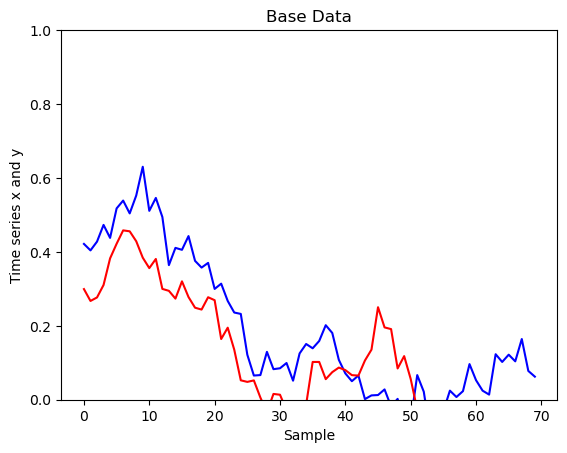

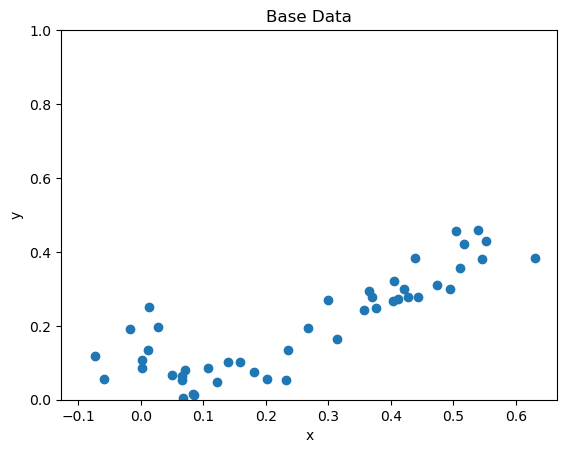

In [4]:
# set up experimental data
seed=2023
#helper fct
def set_seed_everywhere(seed, cuda):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed_all(seed)    
        
set_seed_everywhere(seed,cuda)
n=70 #size of training sample

#random walks
s=0.05
eps_mean = torch.zeros(n)
t_a = torch.normal(eps_mean,s)
t_x = torch.cumsum(t_a,dim = 0) + 0.4 * torch.ones(n)
t_b = torch.normal(eps_mean,s)
t_y = torch.cumsum(t_b,dim = 0) + 0.3 * torch.ones(n)

t_ctr = torch.arange(0, n, step = 1)
t_ctr = t_ctr.clone().detach().unsqueeze(1)
plt.plot(t_ctr, t_x, 'b') # plotting separately 
plt.plot(t_ctr, t_y, 'r') 
plt.ylabel('Time series x and y')
plt.xlabel('Sample')
plt.title('Base Data')
plt.ylim(top = 1)
plt.ylim(bottom = 0)
plt.show()

plt.scatter(t_x, t_y) 
plt.ylabel('y')
plt.xlabel('x')
plt.title('Base Data')
plt.ylim(top = 1)
plt.ylim(bottom = 0)
plt.show()

In [5]:
#NOTE THIS !!! NOTE THIS !!! NOTE THIS !!! NOTE THIS 
#RUN tHIS CELL ONLY ONCE, else you get higher and higher dim by unsqueezing!!!!!!!!

print("before unsqueeze", t_x.shape)
#NOTE that u cannot use this for training! YOU need matrix with n rows and one column
#to get this follow DL Book p. 155
t_x = t_x.clone().detach().unsqueeze(1)#old style torch.tensor(t_x) leads to warning
print("after unsqueeze", t_x.shape)
t_y = t_y.clone().detach().unsqueeze(1)

before unsqueeze torch.Size([70])
after unsqueeze torch.Size([70, 1])


In [6]:
t_m = torch.t(torch.cat((t_x,t_y),1))#transpose cause ...
print("matrix for corr", t_m.shape)#columns are obs AND rows are vars
print("corr", torch.corrcoef(t_m)[1,0].numpy())#only needed for these two moments
print("cov", torch.cov(t_m)[1,0].numpy())

X = t_x.numpy()
X = sm.add_constant(X)
linreg_spurios = sm.OLS(t_y.numpy(), X)

matrix for corr torch.Size([2, 70])
corr 0.78115326
cov 0.030863402


In [7]:
linreg_spurios_results = linreg_spurios.fit()
#linreg_spurios.params
# Inspect the results
print(linreg_spurios_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     106.4
Date:                Thu, 13 Feb 2025   Prob (F-statistic):           1.50e-15
Time:                        14:23:23   Log-Likelihood:                 45.078
No. Observations:                  70   AIC:                            -86.16
Df Residuals:                      68   BIC:                            -81.66
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0734      0.022     -3.382      0.0

Here we present an ideal diagnostic. Doing so reveals that the theorems do not appply!
It does NOT save us to use HAC SE!!!
Since the sample size is small we use level of significance 10%

In [8]:
#############################################################
#                    RESET test for corr spec               #
#############################################################
reset = dg.linear_reset(linreg_spurios_results, power = 4, test_type = 'fitted', use_f = True)
print("Ramsey RESET test with H0: Correct specs: ")
print("F Statistic: ", np.round(reset.fvalue, 4))
print("P Value: ", np.round(reset.pvalue, 4))

Ramsey RESET test with H0: Correct specs: 
F Statistic:  4.4277
P Value:  0.0068


In [9]:
#############################################################
#              t- Test for resis being centered at zero     #
#############################################################

#NOTE: If lin reg with intercept the mean of the resis is 
#zero by construction - so this is just in case
resi = linreg_spurios_results.resid
mean_residuals = np.mean(resi)

# perform t-test 
t_statistic, p_value = stats.ttest_1samp(resi, 0)

# Output results
print(f'Mean of residuals: {mean_residuals}')
print(f't-statistic: {t_statistic}, p-value: {p_value}')

if p_value < 0.1:
    print("The mean of the residuals is significantly different from 0.")
else:
    print("The mean of the residuals is not significantly different from 0.")

Mean of residuals: 7.533656238527847e-18
t-statistic: 4.924233917438887e-16, p-value: 0.9999999999999996
The mean of the residuals is not significantly different from 0.


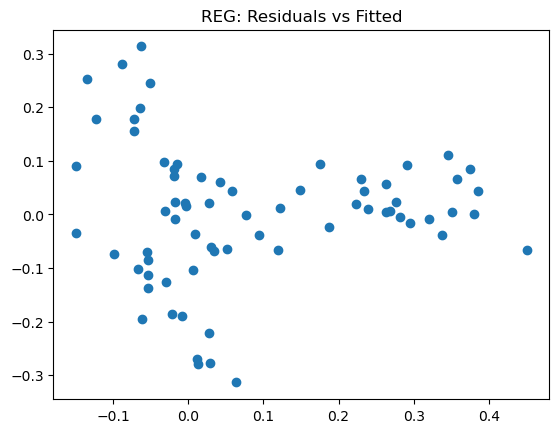

In [10]:
#############################################################
#              any structure in resis visible               #
#############################################################
fc = linreg_spurios_results.fittedvalues
plt.scatter(fc, resi)
plt.title('REG: Residuals vs Fitted')
plt.show()

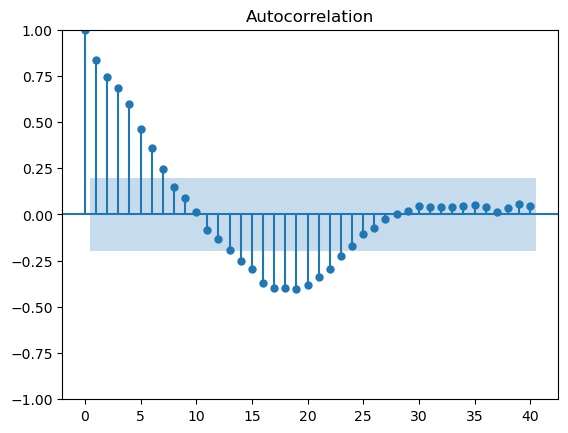

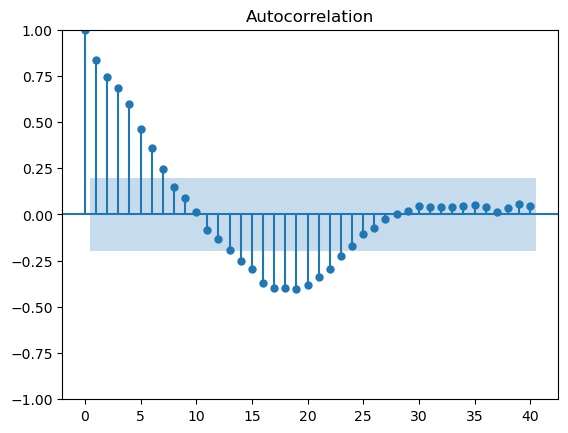

In [11]:
#############################################################
#              does autocorr die down after few lags?       #
#############################################################
plot_acf(resi,lags=40, alpha=.1,bartlett_confint=False)


In [12]:
#############################################################
#                    DW Test for autocorrelation on lag 1   #
#############################################################

dw = sm.stats.durbin_watson(resi)

# Output of the result
print('Durbin-Watson statistic:', dw)
print("If no serial correlation on lag 1, the test statistic equals 2")

Durbin-Watson statistic: 0.2929890687212428
If no serial correlation on lag 1, the test statistic equals 2


In [13]:
#############################################################
#     Breusch-Godfrey test for autocorrelation up to lag 15 #
#############################################################

# Perform in area with highest bars 
#H0: There is no autocorrelation at any order less than or equal to nlags
bg_test = acorr_breusch_godfrey(linreg_spurios_results, nlags=15)  

# Output the result
print('Breusch-Godfrey Test:')
#print(f'LM statistic: {bg_test[0]}')
print(f'p-value: {bg_test[1]}')
print("Reject H0: There is no autocorrelation at any order less than or equal to 15")

Breusch-Godfrey Test:
p-value: 1.747760004431861e-06
Reject H0: There is no autocorrelation at any order less than or equal to 15


Breusch-Pagan p-value: 0.0012867269314686812
Test auf Normalverteilung der Residuen: 


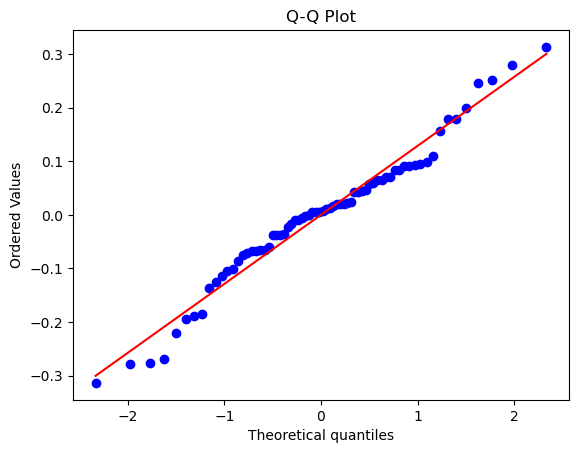

In [14]:
#############################################################
#     Breusch-Pagan test for hetero                         #
#############################################################

#bp requires normal resis, hence check it
#BUT best is to use White below
bp_test_statistic, bp_p_value, _, _ = dg.het_breuschpagan(linreg_spurios_results.resid, X)
print("Breusch-Pagan p-value: " + str(bp_p_value))
print("Test auf Normalverteilung der Residuen: ")
stats.probplot(linreg_spurios_results.resid, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

In [15]:
#############################################################
#     White test for hetero                                 #
#############################################################

print("\n--------------WHITE - TEST------------------------------")#H0: Homo
white_test_statistic, white_p_value, _, _ = dg.het_white(linreg_spurios_results.resid, X)
print("White Test p-value: " + str(white_p_value))
print("Keep H0 of homoscedasticity")


--------------WHITE - TEST------------------------------
White Test p-value: 0.004721862774146558
Keep H0 of homoscedasticity


In [16]:
p_val = 0.2 #percentage for validation

n_samples = t_x.shape[0]
n_val = int(p_val * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices  # <1>

train_t_x = t_x[train_indices]
train_t_y = t_y[train_indices]
val_t_x = t_x[val_indices]
val_t_y = t_y[val_indices]

In [17]:
n_input = 1
n_hidden = 2
n_out = 1

mlp_pt = nn.Sequential(nn.Linear(n_input, n_hidden),
                      nn.Sigmoid(),#the sublayer has n_hidden outputs (right argument)
                     #this has to be the left argument on the following layer 
                      nn.Linear(n_hidden, n_out),
                      nn.Sigmoid())#defines the graph
#mlp_pt = nn.Sequential(nn.Linear(n_input, n_hidden),
 #                     nn.Sigmoid())#defines the graph
#linear is a+bX, then follows a hidden layer of n_hidden-s sigmoids, lienarly fed into a single sigmoid output neuron
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_pt.parameters(), lr=0.02)
losses_train = []
losses_val = []
start_time = time.time()

In [18]:
def training_loop(n_epochs, optimizer, train_t_u, val_t_u,train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = mlp_pt(train_t_u) # <1>
        train_loss = loss_fn(train_t_p, train_t_c)
        losses_train.append(train_loss.item())                    
        with torch.no_grad(): # <1>
            val_t_p = mlp_pt(val_t_u)
            val_loss = loss_fn(val_t_p, val_t_c)
            losses_val.append(val_loss.item()) 
            assert val_loss.requires_grad == False 
            
        optimizer.zero_grad()
        train_loss.backward() # <2>
        optimizer.step()

        if epoch <= 10 or epoch % 100 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                  f" Validation loss {val_loss.item():.4f}")
            
    return 

n_epoch = 100
training_loop(
    n_epochs = n_epoch, 
    optimizer = optimizer,
    train_t_u = train_t_x, 
    val_t_u = val_t_x, 
    train_t_c = train_t_y,
    val_t_c = val_t_y)

Epoch 1, Training loss 0.4330, Validation loss 0.5219
Epoch 2, Training loss 0.4204, Validation loss 0.5079
Epoch 3, Training loss 0.4078, Validation loss 0.4938
Epoch 4, Training loss 0.3953, Validation loss 0.4799
Epoch 5, Training loss 0.3829, Validation loss 0.4659
Epoch 6, Training loss 0.3705, Validation loss 0.4521
Epoch 7, Training loss 0.3584, Validation loss 0.4384
Epoch 8, Training loss 0.3463, Validation loss 0.4248
Epoch 9, Training loss 0.3345, Validation loss 0.4114
Epoch 10, Training loss 0.3229, Validation loss 0.3982
Epoch 100, Training loss 0.0406, Validation loss 0.0491


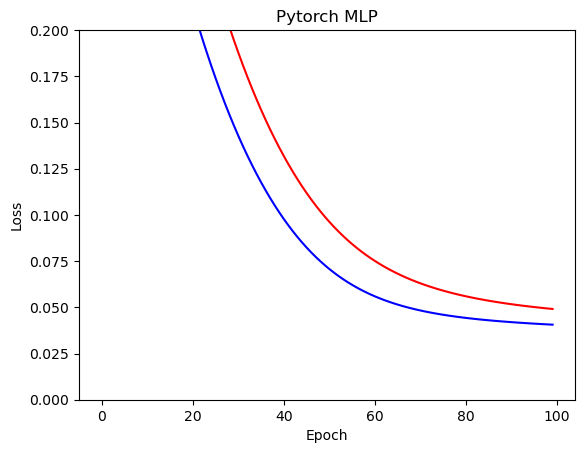

In [19]:
t_ctr = torch.arange(0, n_epoch, step = 1)
t_ctr = t_ctr.clone().detach().unsqueeze(1)
plt.plot(t_ctr, losses_train, 'b') # plotting separately 
plt.plot(t_ctr, losses_val, 'r') 
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Pytorch MLP')
plt.ylim(top = 0.2)
plt.ylim(bottom = 0)
plt.show()

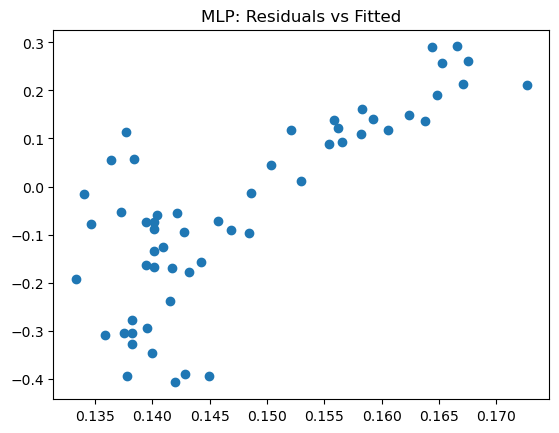

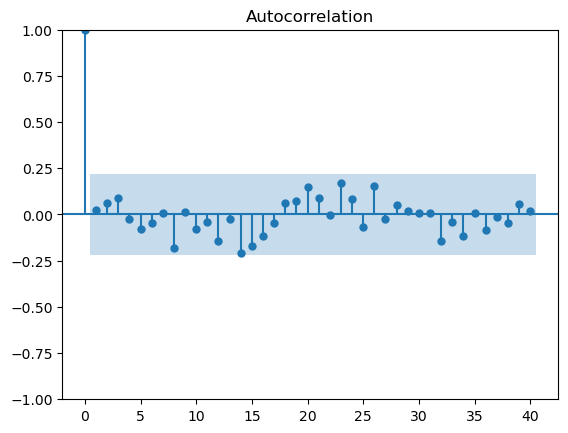

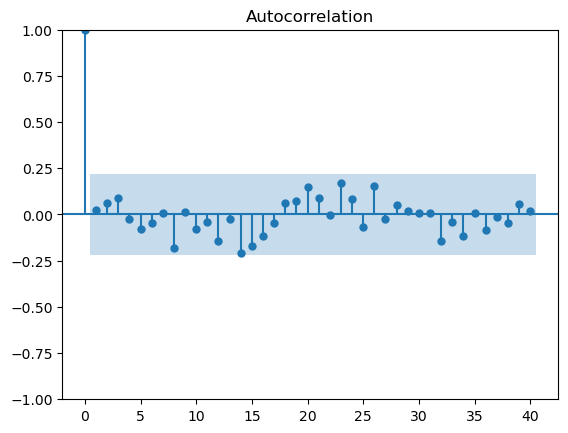

In [20]:
t_fc = mlp_pt(train_t_x).detach().numpy()
t_resi = train_t_y-t_fc
plt.scatter(t_fc, t_resi.data.numpy())
plt.title('MLP: Residuals vs Fitted')
plt.show()

plot_acf(np.array(t_resi.data.numpy()),lags=40, alpha=.1,bartlett_confint=False)
#choose 10% cause sample is small

In [21]:
t_m = torch.t(torch.cat((mlp_pt(train_t_x),train_t_y),1))#transpose cause ...
print("REG R2 is", round(linreg_spurios_results.rsquared,3))
print("MLP R2 is", round(torch.corrcoef(t_m)[1,0].detach().numpy()*torch.corrcoef(t_m)[1,0].detach().numpy(),3))

print('\n Training needed: %s seconds---' % (time.time() - start_time))

REG R2 is 0.61
MLP R2 is 0.636

 Training needed: 0.7983264923095703 seconds---


In [22]:
print("DONE")

DONE
